# Day 4

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import keras
from keras import layers

## 텍스트 분류 데이터

In [ ]:
from pathlib import Path
import sentencepiece as spm
from text import TextDataset

%run text.py

폴더 = Path('data/koen')

tokenizer = spm.SentencePieceProcessor()
tokenizer.load('spm.model')

def 전처리(text, 최대길이):
    정수시퀀스 = tokenizer.encode(text, out_type=int)    
    return 정수시퀀스[:최대길이]

datasets = {}
for split, 샘플수 in [('train', 10000), ('validation', 1000), ('test', 1000)]:
    frame = pd.read_csv(폴더 / f'{split}.csv')
    frame.dropna(inplace=True) # 결측값 제거
    # 각 클래스에서 샘플링
    구어체 = frame[frame['source'] == 71265].sample(샘플수, random_state=0)
    특허 = frame[frame['source'] == 563].sample(샘플수, random_state=0)

    samples = pd.concat([구어체, 특허], ignore_index=True)
    
    datasets[split] = TextDataset(
        texts=samples['ko'].tolist(),
        # 텍스트 분류를 위해 클래스 레이블도 함께 제공해야 합니다.
        labels=samples['source'].map({71265: 0, 563: 1}).tolist(),
        transform=lambda text: 전처리(text, 최대길이=300)
    )
    print(f'{split:<10}: {len(datasets[split]):,}')
    # 유형 도수 확인
    print(samples['source'].value_counts().to_string())

train     : 20,000
source
71265    10000
563      10000
validation: 2,000
source
71265    1000
563      1000
test      : 2,000
source
71265    1000
563      1000


In [ ]:
from text import 배치병합

dataloaders = {}
for split in datasets.keys():
    dataloaders[split] = torch.utils.data.DataLoader(
        datasets[split], shuffle=(split=='train'),
        batch_size=32, num_workers=2, collate_fn=배치병합
    )

배치시퀀스길이 = []
for X_batch, y_batch in dataloaders['train']:
    # print(X_batch.shape, y_batch.shape)
    배치시퀀스길이.append(X_batch.shape[1])

pd.Series(배치시퀀스길이).describe().astype(int)

count    625
mean     241
std       38
min      147
25%      210
50%      235
75%      275
max      300
dtype: int64

## RNN

In [9]:
import keras
from keras import layers

keras.backend.clear_session()

어휘수 = tokenizer.get_piece_size()
print(f'어휘 수: {어휘수:,}')
model = keras.Sequential([
    keras.Input(shape=(None,)), # 가변 길이 시퀀스 입력
    layers.Embedding(input_dim=어휘수, output_dim=128), # 임베딩
    # 은닉층
    layers.LSTM(32), # RNN 계열의 LSTM 층
    # 출력층
    layers.Dense(1, activation='sigmoid') # 이진 분류
])
model.summary()

model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=['acc'],
)

history = model.fit(
    dataloaders['train'], epochs=10,
    validation_data=dataloaders['validation'],
    callbacks=[
        keras.callbacks.ModelCheckpoint(
            'text_classifier-RNN.keras', save_best_only=True)
    ]
)

어휘 수: 30,000


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 128)      │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,860,641 (14.73 MB)

 Trainable params: 3,860,641 (14.73 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 247s 394ms/step - acc: 0.7511 - loss: 0.4520 - val_acc: 0.8975 - val_loss: 0.3155
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 256s 409ms/step - acc: 0.8049 - loss: 0.4159 - val_acc: 0.6560 - val_loss: 1.0512
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 247s 395ms/step - acc: 0.9928 - loss: 0.0412 - val_acc: 0.8995 - val_loss: 0.2785
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 252s 403ms/step - acc: 0.9975 - loss: 0.0150 - val_acc: 0.9395 - val_loss: 0.1844
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 250s 400ms/step - acc: 0.9993 - loss: 0.0060 - val_acc: 0.9585 - val_loss: 0.1338
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 254s 406ms/step - acc: 0.9994 - loss: 0.0043 - val_acc: 0.9505 - val_loss: 0.1953
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 254s 407ms/step - acc: 0.9995 - loss: 0.0034 - val_acc: 0.9425 - val_loss: 0.1656
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 253s 405ms/step - acc: 0.9994 - loss: 0.0030 - val_acc: 0.9730 - val_loss: 0.0872
Epoch 9/10
625/625 ━━━━━

In [10]:
model = keras.models.load_model('text_classifier-RNN.keras')
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 128)      │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,581,925 (44.18 MB)

 Trainable params: 3,860,641 (14.73 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,721,284 (29.45 MB)

In [16]:
임베딩행렬 = model.layers[0].get_weights()[0]
print(임베딩행렬.shape)

단어 = '사랑'
정수인덱스 = tokenizer.piece_to_id(단어)
print(f'{단어} -> {정수인덱스}')
임베딩벡터 = 임베딩행렬[정수인덱스]
print(f'임베딩 벡터: {임베딩벡터[:5].round(3)}...')

(30000, 128)
사랑 -> 23158
임베딩 벡터: [0.049 0.018 0.046 0.032 0.036]...


In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

유사도행렬 = cosine_similarity(임베딩행렬)

In [23]:
print(유사도행렬.shape)
어휘목록 = tokenizer.id_to_piece(list(range(어휘수)))
유사도프레임 = pd.DataFrame(유사도행렬, index=어휘목록, columns=어휘목록)
유사도프레임.round(3)

(30000, 30000)


,<pad>,<unk>,<s>,</s>,.,▁the,",",▁of,▁,▁a,...,널,템,좋,겠,높,많,같,않,볍,했
<pad>,1.000,0.504,-0.126,0.100,-0.083,0.031,0.224,0.102,0.373,-0.039,...,0.109,0.081,0.099,-0.119,0.396,0.240,0.368,-0.378,0.050,-0.197
<unk>,0.504,1.000,-0.030,0.056,0.335,0.050,0.551,0.186,0.593,0.090,...,0.135,0.346,0.400,0.043,0.341,0.232,0.424,0.041,0.125,-0.007
<s>,-0.126,-0.030,1.000,0.068,0.045,0.109,-0.008,-0.013,-0.022,0.060,...,0.065,0.175,0.113,0.037,-0.057,0.122,-0.068,0.052,-0.050,0.096
</s>,0.100,0.056,0.068,1.000,-0.009,-0.059,0.054,0.041,-0.011,0.118,...,-0.040,-0.021,-0.201,-0.111,0.104,0.071,-0.000,0.101,0.078,0.047
.,-0.083,0.335,0.045,-0.009,1.000,-0.021,0.476,-0.050,0.491,0.606,...,-0.012,0.219,0.141,-0.330,0.486,-0.241,0.231,0.532,0.045,0.168
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
많,0.240,0.232,0.122,0.071,-0.241,0.056,-0.016,0.084,-0.089,-0.429,...,-0.054,0.167,0.117,0.500,-0.228,1.000,0.199,-0.327,0.120,-0.201
같,0.368,0.424,-0.068,-0.000,0.231,-0.056,0.533,0.159,0.223,0.091,...,0.293,0.509,0.167,-0.084,0.346,0.199,1.000,0.048,0.100,0.001
않,-0.378,0.041,0.052,0.101,0.532,0.070,0.417,0.023,0.148,0.414,...,0.077,0.173,0.017,-0.345,0.173,-0.327,0.048,1.000,-0.007,0.358
볍,0.050,0.125,-0.050,0.078,0.045,0.019,0.059,0.089,0.002,-0.045,...,0.145,-0.001,-0.028,0.108,0.001,0.120,0.100,-0.007,1.000,-0.041


In [46]:
단어 = '대통령'
# 거리 (유사도) 순 상위 10개 단어
정수인덱스 = tokenizer.piece_to_id(단어)
유사도프레임.iloc[정수인덱스].sort_values(ascending=False).head(5).round(3).to_frame()

,대통령
대통령,1.000
▁analog,0.361
사무소,0.354
▁might,0.342
대표,0.329


## 트랜스포머

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, None, 128) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, None, 128) │     66,048 │ input_layer_5[0]… │
│ (MultiHeadAttentio… │                   │            │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, None, 128) │          0 │ multi_head_atten… │
│                     │                   │            │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, None, 128) │        256 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_3        │ (None, None, 128) │     65,920 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_5 (Add)         │ (None, None, 128) │          0 │ sequential_3[0][… │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, None, 128) │        256 │ add_5[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 132,480 (517.50 KB)

 Trainable params: 132,480 (517.50 KB)

 Non-trainable params: 0 (0.00 B)

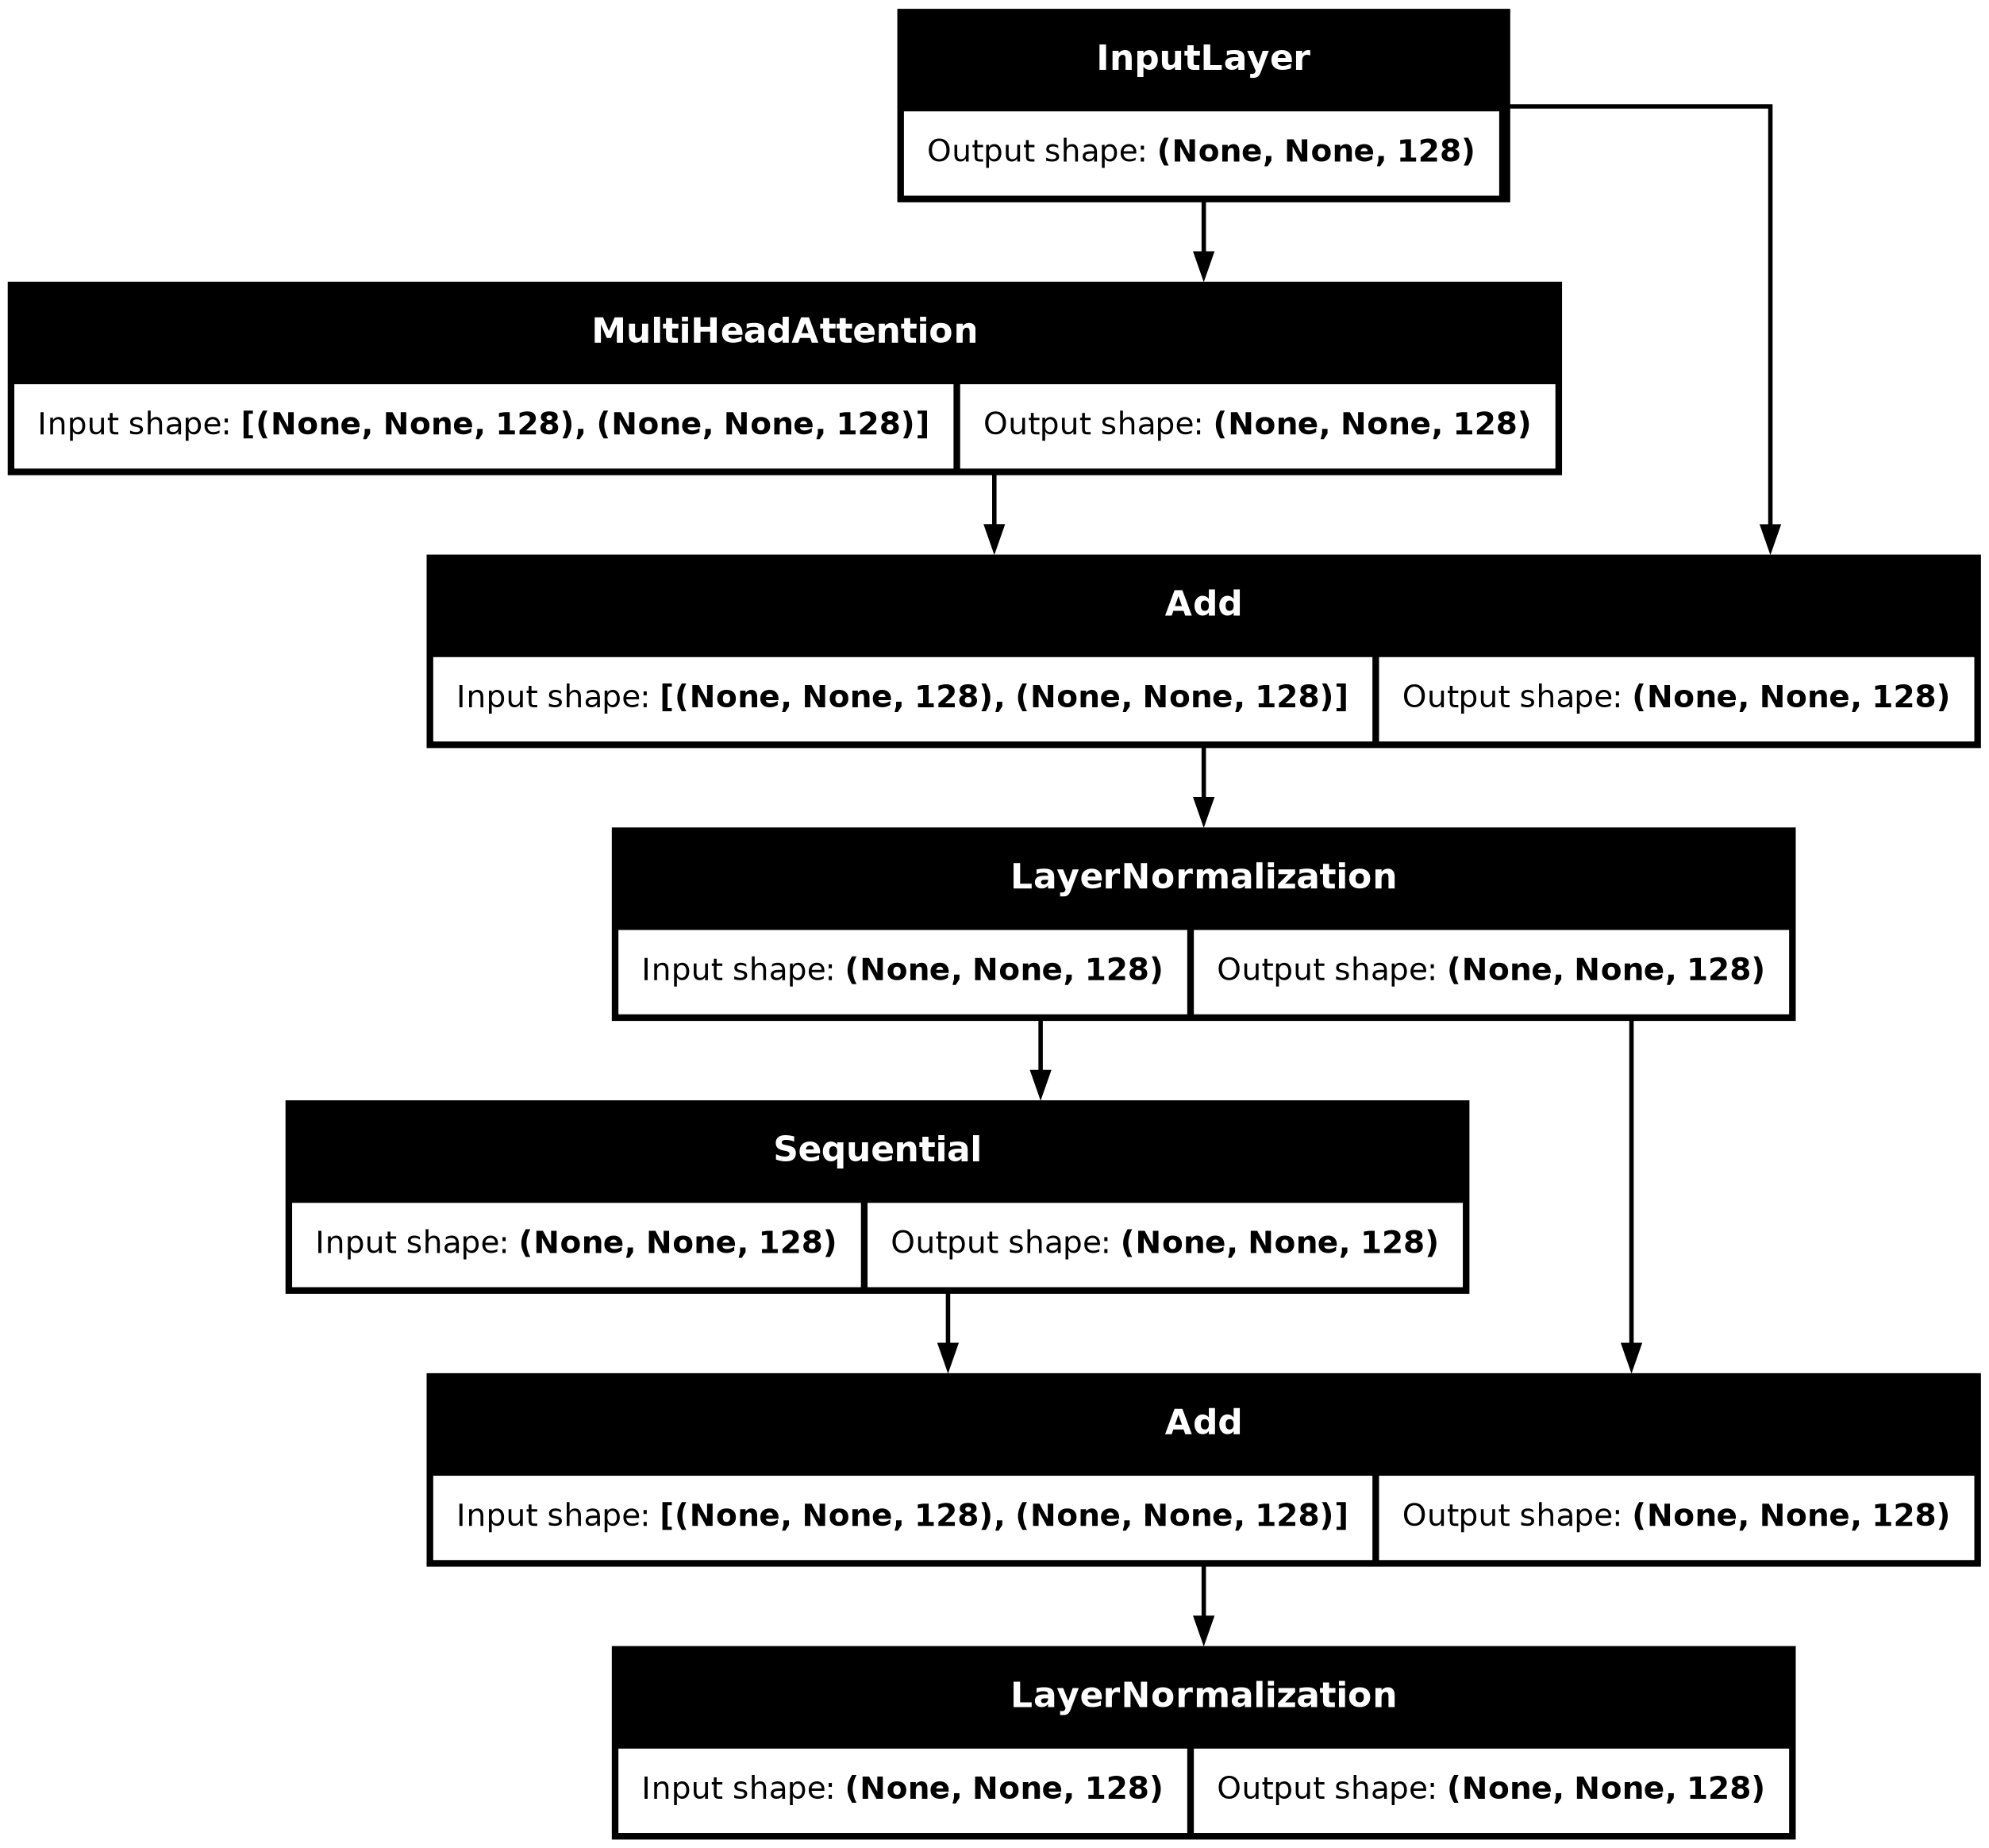

In [ ]:
def get_encoder(inputs, 임베딩차원, 멀티헤드수, 잠재차원):
    # 계층 정의
    어텐션계층 = layers.MultiHeadAttention(
        num_heads=멀티헤드수, key_dim=임베딩차원 // 멀티헤드수)
    mlp = keras.Sequential([
        layers.Dense(잠재차원, activation='relu'),
        layers.Dense(임베딩차원)
    ])
    # 모델 구성
    # 1. 셀프 어텐션
    x0 = inputs
    Q, K = inputs, inputs
    x = 어텐션계층(Q, K) # Query = Key => 셀프 어텐션
    x = layers.LayerNormalization()(x + x0) # 층 정규화 (layer normalization)
    # 2. MLP
    x0 = x
    x = mlp(x)
    x = layers.LayerNormalization()(x + x0) # 층 정규화 (layer normalization)
    model = keras.Model(inputs, x)
    return model

inputs = keras.Input(shape=(None, 128)) # (배치 크기, 시퀀스 길이, 임베딩 차원)
encoder = get_encoder(inputs, 임베딩차원=128, 멀티헤드수=4, 잠재차원=256)
encoder.summary()

keras.utils.plot_model(encoder, show_shapes=True)

### 어텐션

$$
Q = XW^Q, \quad K = XW^K, \quad V = XW^V
$$

$$
\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

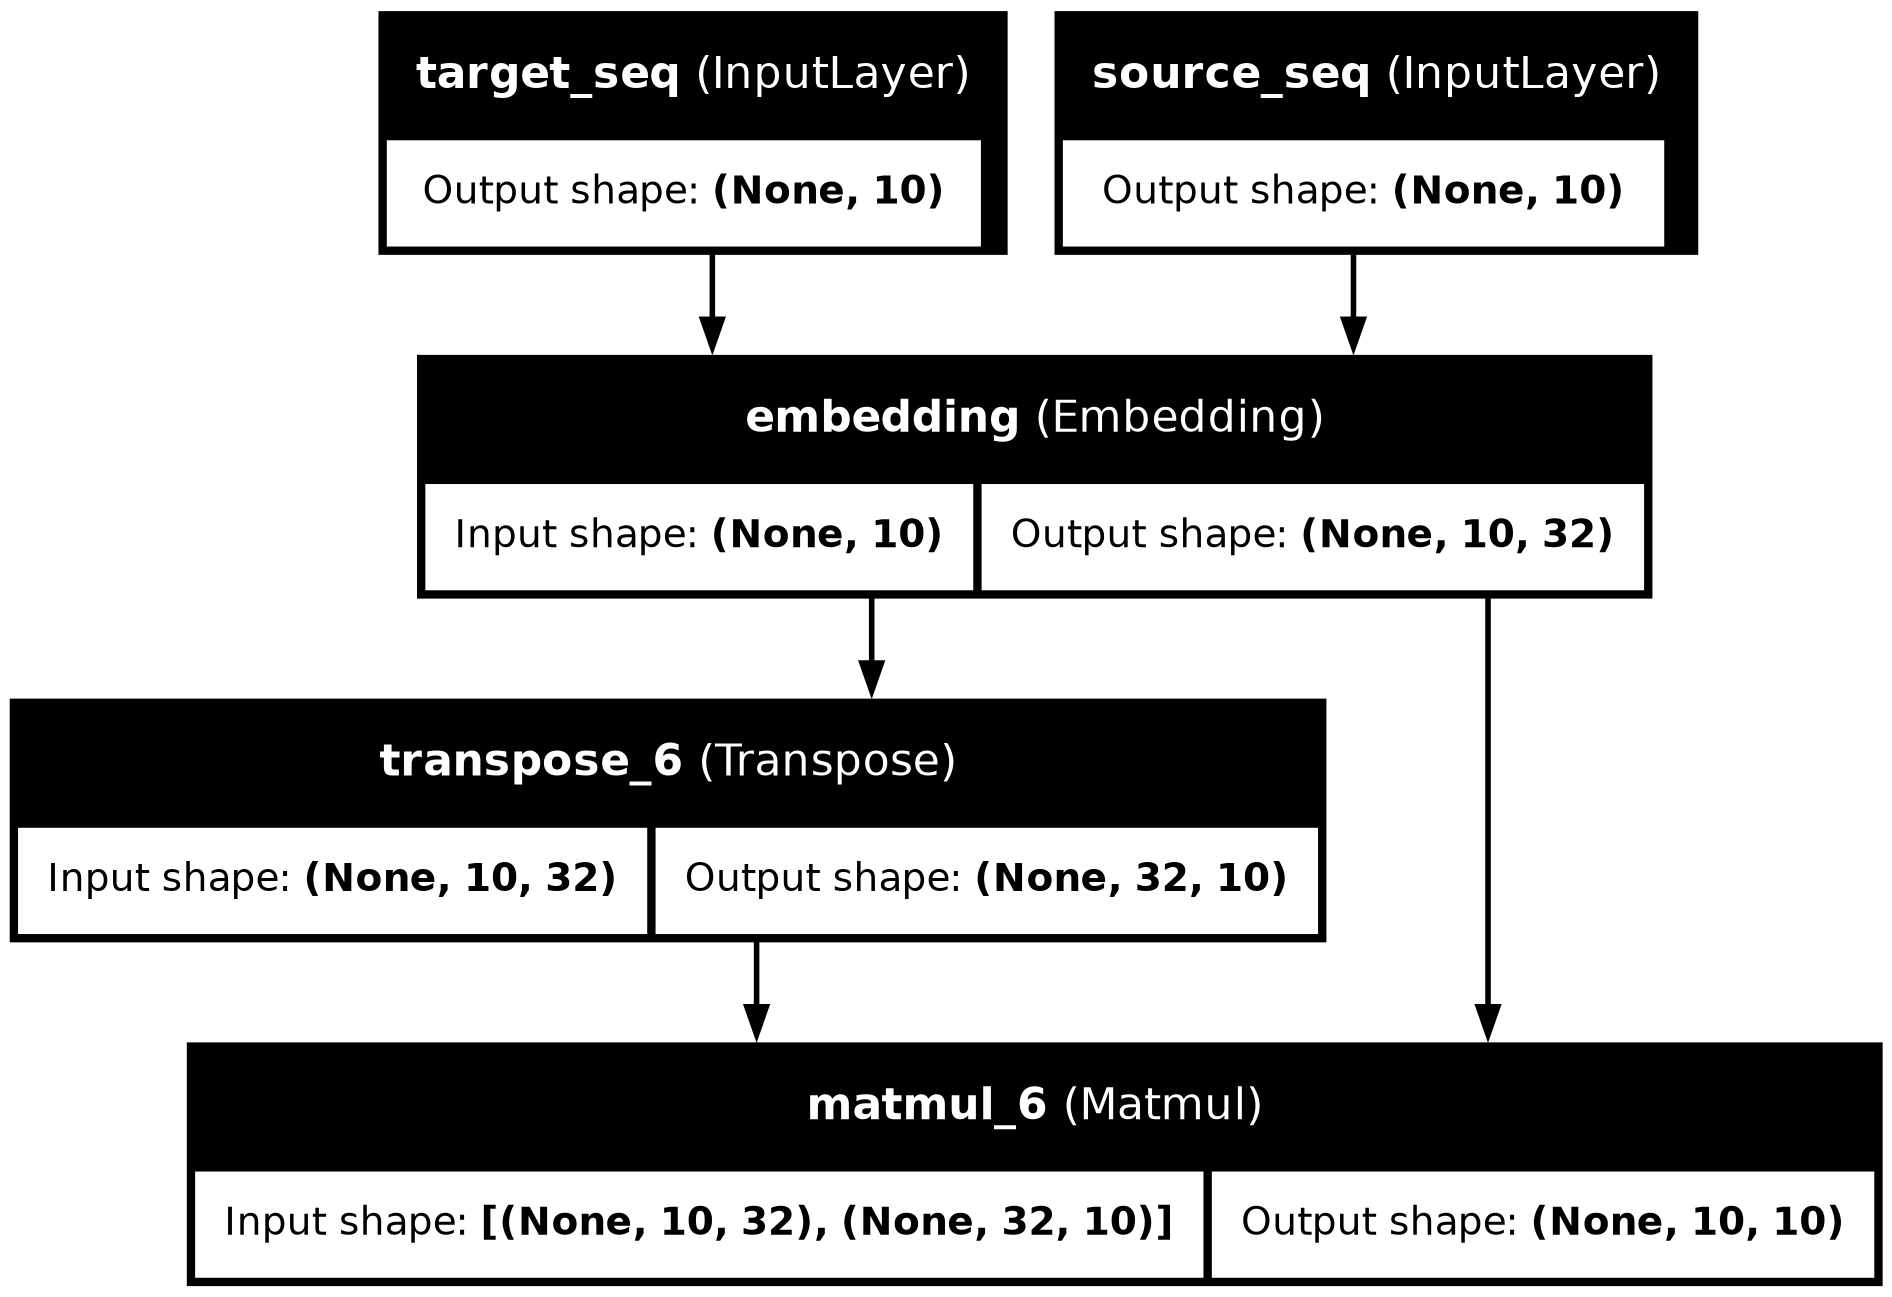

In [11]:
시퀀스길이 = 10; 임베딩차원 = 32; 어휘수 = 100
query = keras.Input(shape=(시퀀스길이,), name='target_seq') # 예: 번역 목표 문장
key = keras.Input(shape=(시퀀스길이,), name='source_seq')   # 예: 번역 원문

임베딩 = layers.Embedding(input_dim=어휘수, output_dim=임베딩차원, name='embedding')
# 각 문장의 단어는 임베딩 차원 크기의 벡터로 변환됩니다. (배치 크기, 시퀀스 길이, 임베딩 차원)
Q = 임베딩(query) # (배치 크기, 시퀀스 길이, 임베딩 차원)
K = 임베딩(key) # (배치 크기, 시퀀스 길이, 임베딩 차원)

# Q와 K의 내적을 계산하여 어텐션 점수를 구합니다. QK^T
# 유사도 행렬이 됩니다.
KT = keras.ops.transpose(K, axes=(0, 2, 1)) # (배치 크기, 임베딩 차원, 시퀀스 길이)
어텐션점수 = keras.ops.matmul(Q, KT) # (배치 크기, 시퀀스 길이, 시퀀스 길이)

model = keras.Model(inputs=[query, key], outputs=어텐션점수)
# model.summary()
keras.utils.plot_model(model, show_shapes=True, show_layer_names=True)

#### Cross Attention

In [ ]:
query_seq = np.random.randint(0, 어휘수, size=(1, 시퀀스길이)) # (1, 시퀀스 길이)
key_seq = np.random.randint(0, 어휘수, size=(1, 시퀀스길이))   # (1, 시퀀스 길이)

display(pd.DataFrame({'query_seq': query_seq.flatten(), 'key_seq': key_seq.flatten()}).T)

어텐션점수 = model.predict([query_seq, key_seq])
어텐션점수 = 어텐션점수.squeeze() # (시퀀스 길이, 시퀀스 길이)
print(f'어텐션 점수 행렬 크기: {어텐션점수.shape}')
display(pd.DataFrame(어텐션점수, index=query_seq.flatten(), columns=key_seq.flatten()).round(3))

,0,1,2,3,4,5,6,7,8,9
query_seq,98,35,32,71,53,57,59,65,35,3
key_seq,63,88,0,66,26,41,34,94,20,89


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
어텐션 점수 행렬 크기: (10, 10)


,63,88,0,66,26,41,34,94,20,89
98,0.001,-0.009,-0.004,-0.006,-0.000,-0.002,0.000,0.007,-0.002,0.001
35,-0.001,-0.009,0.003,-0.001,0.005,-0.005,-0.001,0.002,0.001,-0.005
32,0.004,0.000,0.001,-0.001,-0.006,-0.002,-0.004,0.007,-0.002,0.003
71,-0.000,-0.003,-0.009,0.002,0.006,-0.004,0.001,-0.002,-0.006,-0.001
53,-0.005,-0.006,0.009,-0.002,-0.001,-0.006,0.001,0.005,0.001,0.003
57,0.004,-0.002,-0.004,-0.005,-0.003,-0.001,0.005,0.002,-0.006,-0.000
59,0.003,0.000,-0.004,0.006,0.008,-0.007,0.002,-0.005,0.001,-0.004
65,-0.003,-0.006,-0.001,-0.007,0.003,0.003,-0.007,-0.007,0.009,-0.008
35,-0.001,-0.009,0.003,-0.001,0.005,-0.005,-0.001,0.002,0.001,-0.005
3,-0.003,0.005,-0.010,0.011,0.005,-0.003,0.004,0.003,-0.010,-0.003


#### Self Attention

Query = Key = Value = 같은 시퀀스에서 나온 벡터들

In [18]:
query_seq = np.random.randint(0, 어휘수, size=(1, 시퀀스길이)) # (1, 시퀀스 길이)

display(pd.DataFrame({'query_seq': query_seq.flatten(), 'key_seq': query_seq.flatten()}).T)

어텐션점수 = model.predict([query_seq, query_seq])
어텐션점수 = 어텐션점수.squeeze() # (시퀀스 길이, 시퀀스 길이)
print(f'어텐션 점수 행렬 크기: {어텐션점수.shape}')
display(pd.DataFrame(어텐션점수, index=query_seq.flatten(), columns=query_seq.flatten()).round(3))

,0,1,2,3,4,5,6,7,8,9
query_seq,23,65,12,2,27,96,41,4,49,39
key_seq,23,65,12,2,27,96,41,4,49,39


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
어텐션 점수 행렬 크기: (10, 10)


,23,65,12,2,27,96,41,4,49,39
23,0.024,0.001,0.006,0.001,0.002,-0.002,-0.005,0.008,-0.009,-0.001
65,0.001,0.027,0.001,0.004,0.001,0.005,0.003,0.005,0.003,-0.008
12,0.006,0.001,0.022,0.000,0.002,0.006,-0.009,-0.004,-0.002,0.009
2,0.001,0.004,0.000,0.023,0.002,0.001,-0.003,-0.007,-0.000,0.008
27,0.002,0.001,0.002,0.002,0.028,-0.002,0.002,0.000,-0.010,-0.002
96,-0.002,0.005,0.006,0.001,-0.002,0.032,-0.001,-0.008,0.006,-0.003
41,-0.005,0.003,-0.009,-0.003,0.002,-0.001,0.035,0.002,0.010,-0.006
4,0.008,0.005,-0.004,-0.007,0.000,-0.008,0.002,0.022,-0.008,-0.010
49,-0.009,0.003,-0.002,-0.000,-0.010,0.006,0.010,-0.008,0.026,0.003
39,-0.001,-0.008,0.009,0.008,-0.002,-0.003,-0.006,-0.010,0.003,0.029


#### Multi-Head Attention

In [25]:
query_seq = np.random.randint(0, 어휘수, size=(1, 시퀀스길이)) # (1, 시퀀스 길이)
key_seq = np.random.randint(0, 어휘수, size=(1, 시퀀스길이))   # (1, 시퀀스 길이)

display(pd.DataFrame({'query_seq': query_seq.flatten(), 'key_seq': key_seq.flatten()}).T)

# 멀티헤드 어텐션
임베딩차원 = 128; 멀티헤드수 = 4
임베딩 = layers.Embedding(
    input_dim=어휘수, output_dim=임베딩차원, name='embedding')
Q = 임베딩(query_seq) # (배치 크기, 시퀀스 길이, 임베딩 차원)
K = 임베딩(key_seq) # (배치 크기, 시퀀스 길이, 임베딩 차원)

# 멀티헤드
head_projections = [layers.Dense(임베딩차원 // 멀티헤드수) for _ in range(멀티헤드수)]
heads = []
for i in range(멀티헤드수):
    Qi = head_projections[i](Q) # (배치 크기, 시퀀스 길이, 임베딩 차원 // 멀티헤드수)
    Ki = head_projections[i](K) # (배치 크기, 시퀀스 길이, 임베딩 차원 // 멀티헤드수)
    KTi = keras.ops.transpose(Ki, axes=(0, 2, 1)) # (배치 크기, 임베딩 차원 // 멀티헤드수, 시퀀스 길이)
    어텐션점수i = keras.ops.matmul(Qi, KTi) # (배치 크기, 시퀀스 길이, 시퀀스 길이)
    heads.append(어텐션점수i)

,0,1,2,3,4,5,6,7,8,9
query_seq,93,30,79,17,41,77,90,62,94,78
key_seq,91,50,63,75,46,51,81,45,56,22


In [ ]:
멀티헤드어텐션 = keras.layers.MultiHeadAttention(num_heads=멀티헤드수, key_dim=임베딩차원 // 멀티헤드수)

xq = 임베딩(query_seq) # (배치 크기, 시퀀스 길이, 임베딩 차원)
xk = 임베딩(key_seq) # (배치 크기, 시퀀스 길이, 임베딩 차원)
어텐션출력 = 멀티헤드어텐션(query=xq, value=xk, key=xk)
print(f'멀티헤드 어텐션 출력 크기: {어텐션출력.shape}') # (배치 크기, 시퀀스 길이, 임베딩 차원)

멀티헤드 어텐션 출력 크기: torch.Size([1, 10, 128])


## 텍스트 분류 트랜스포머

In [4]:
import keras
from keras import layers
# transformer.py 파일에서 TransformerEncoder 클래스를 가져옵니다.
from transformer import TransformerEncoder

keras.backend.clear_session()

def build_model(어휘수, 임베딩차원, 멀티헤드수, 잠재차원):
    model = keras.Sequential([
        keras.Input(shape=(None,)), # 가변 길이 시퀀스 입력
        layers.Embedding(input_dim=어휘수, output_dim=임베딩차원, mask_zero=True), # 임베딩
        # 은닉층
        TransformerEncoder(embed_dim=임베딩차원, num_heads=멀티헤드수, dense_dim=잠재차원),
        # 출력층
        layers.GlobalAveragePooling1D(), # 벡터화
        layers.Dense(1, activation='sigmoid') # 이진 분류
    ])
    return model

model = build_model(어휘수=30000, 임베딩차원=128, 멀티헤드수=4, 잠재차원=256)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, None, 128)      │     3,840,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder             │ (None, None, 128)      │       330,240 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,170,369 (15.91 MB)

 Trainable params: 4,170,369 (15.91 MB)

 Non-trainable params: 0 (0.00 B)

In [5]:
%run load_text_class_example.py

model.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer=keras.optimizers.Adam(),
    metrics=['acc'],
)

history = model.fit(
    dataloaders['train'], epochs=10,
    validation_data=dataloaders['validation'],
    callbacks=[
        keras.callbacks.ModelCheckpoint(
            'text_classifier-transformer.keras', save_best_only=True)
    ]
)

train     : 20,000
validation: 2,000
test      : 2,000
train      배치 수: 625
validation 배치 수: 63
test       배치 수: 63
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - acc: 0.9612 - loss: 0.0888 - val_acc: 0.9935 - val_loss: 0.0211
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - acc: 0.9991 - loss: 0.0029 - val_acc: 0.9890 - val_loss: 0.0531
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - acc: 0.9999 - loss: 1.7335e-04 - val_acc: 0.9905 - val_loss: 0.0573
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - acc: 0.9999 - loss: 2.7991e-04 - val_acc: 0.9905 - val_loss: 0.0595
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - acc: 0.9987 - loss: 0.0038 - val_acc: 0.9885 - val_loss: 0.0526
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 29ms/step - acc: 0.9995 - loss: 0.0021 - val_acc: 0.9910 - val_loss: 0.0373
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - acc: 1.0000 - loss: 1.1902e-04 - val_acc: 0.9945 - val_loss: 0.0301
Epoch 8/10
625/625 ━━━━━━━━━━━━━